风格迁移

(1) 定义 Gram 矩阵 (用于提取风格特征)

In [17]:
def get_gram_matrix(tensor):
    """ 计算 Gram 矩阵，代表颜色和纹理的关联 """
    b, c, h, w = tensor.size()
    features = tensor.view(b * c, h * w)
    gram = torch.mm(features, features.t()) # 矩阵乘法
    return gram.div(b * c * h * w) # 标准化

(2) 训练循环逻辑

In [18]:
def run_style_transfer(content_img, style_img, model, num_steps=300, style_weight=1000000, content_weight=1):
    # 将输入图像初始化为内容图，并设为可学习
    input_img = content_img.clone().detach().requires_grad_(True)
    optimizer = optim.LBFGS([input_img]) # 风格迁移常用 LBFGS 优化器

    # 预先提取内容和风格的特征目标 (Target)
    with torch.no_grad():
        target_content_features = get_features(content_img, model)
        target_style_features = get_features(style_img, model)
        style_grams = {layer: get_gram_matrix(target_style_features[layer]) for layer in target_style_features}

    step = [0]
    while step[0] <= num_steps:
        def closure():
            optimizer.zero_grad()
            input_features = get_features(input_img, model)
            
            # 计算内容损失 (MSE)
            c_loss = torch.mean((input_features['conv4_2'] - target_content_features['conv4_2'])**2)
            
            # 计算风格损失 (多层 Gram 矩阵误差之和)
            s_loss = 0
            for layer in style_grams:
                input_gram = get_gram_matrix(input_features[layer])
                s_loss += torch.mean((input_gram - style_grams[layer])**2)
            
            total_loss = content_weight * c_loss + style_weight * s_loss
            total_loss.backward()
            
            step[0] += 1
            if step[0] % 50 == 0:
                print(f"Step {step[0]}: Total Loss: {total_loss.item()}")
            return total_loss

        optimizer.step(closure)
        input_img.data.clamp_(0, 1)

    return input_img

In [19]:
# 启动增强
import torch
# 配置信息
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"训练设备: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

训练设备: cuda:0
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


(3) 调用VGG19完成训练

/tmp/ipykernel_23626/1839246440.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


本地权重加载成功！
Step 50: Total Loss: 2.881575345993042
Step 100: Total Loss: 2.6712212562561035
Step 150: Total Loss: 2.6031301021575928
Step 200: Total Loss: 2.566633701324463


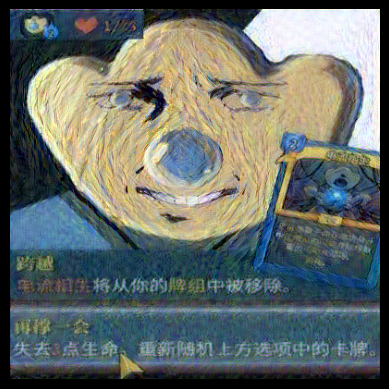

In [23]:
import torch
from torch import nn #建立模型的库
from torch.nn import functional as F#损失函数 激活函数
from torch import optim#优化器 SGD
from torch.utils.data import Dataset, DataLoader#读取外部数据 将数据加载入模型
import torchvision#数据预处理 内置数据集
from matplotlib import pyplot as plt#画图
import torchvision.transforms as T#数据预处理
import os#文件处理
from PIL import Image#载入 显示图片
import torch
import torch.optim as optim
from torchvision import models, transforms

# 准备图片和模型
# 注意：内容图和风格图必须缩放到同样的大小
transform = T.Compose([T.Resize((400, 400)), T.ToTensor()])

content_img = transform(Image.open("鸡煲笑话.jpg")).unsqueeze(0)
style_img = transform(Image.open("2.jpg")).unsqueeze(0)

# 定义加载本地 VGG 的函数
path='vgg19-dcbb9e9d.pth'
def load_local_vgg19(path='vgg19-dcbb9e9d.pth'): # 模型文件保留在本代码相同路径下即可
    model = models.vgg19(weights=None)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path))
        print("本地权重加载成功！")
    else:
        print("未找到本地文件，请检查路径。")
    return model.features.eval() # 返回 features 部分用于实验

vgg = load_local_vgg19('vgg19-dcbb9e9d.pth').eval()

def get_features(image, model):
    layers = {'0': 'conv1_1', '5': 'conv2_1', '10': 'conv3_1', '19': 'conv4_1', '21': 'conv4_2', '28': 'conv5_1'}
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

# 开始迁移
output = run_style_transfer(content_img, style_img, vgg, num_steps=200, style_weight=1e6)

# 显示结果
final_img = T.ToPILImage()(output.squeeze(0))
plt.imshow(final_img)
plt.axis('off')
plt.show()

DEEP DREAM

/tmp/ipykernel_23626/868387875.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


本地权重加载成功！


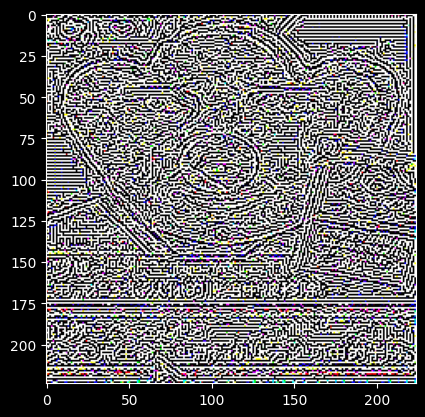


(eog:7224): Gtk-WARNING **: 17:13:34.187: cannot open display: 10.255.255.254:0.0


In [22]:
import torch
from torch import nn #建立模型的库
from torch.nn import functional as F#损失函数 激活函数
from torch import optim#优化器 SGD
from torch.utils.data import Dataset, DataLoader#读取外部数据 将数据加载入模型
import torchvision#数据预处理 内置数据集
from matplotlib import pyplot as plt#画图
import torchvision.transforms as T#数据预处理
import os#文件处理
from PIL import Image#载入 显示图片


import torch
import torch.optim as optim
from torchvision import models, transforms

def deep_dream(image_tensor, model, layer_index, iterations=20, lr=0.1):
    input_img = image_tensor.clone().detach().requires_grad_(True)
    optimizer = optim.Adam([input_img], lr=lr)
    
    modules = list(model.children()) 
    
    for i in range(iterations):
        optimizer.zero_grad()
        
        # 前向传播到指定层
        x = input_img
        for j in range(layer_index + 1):
            x = modules[j](x)
            
        loss = -x.norm()
        loss.backward()
        optimizer.step()
        input_img.data.clamp_(0, 1)
        
    return input_img.detach()

# 定义加载本地 VGG 的函数
def load_local_vgg16(path='vgg16-397923af.pth'):
    model = models.vgg16(weights=None)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path))
        print("本地权重加载成功！")
    else:
        print("未找到本地文件，请检查路径。")
    return model.features.eval() # 返回 features 部分用于实验

# 载入预训练模型 (VGG16的特征提取部分)
#vgg = torchvision.models.vgg16(pretrained=True).features.eval()

vgg = load_local_vgg16('vgg16-397923af.pth').eval()

# 读取并预处理图片
img_path = "鸡煲笑话.jpg" # 换成你的图片路径
img = Image.open(img_path).convert('RGB')
transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
img_tensor = transform(img).unsqueeze(0) # 增加 batch 维度

# 调用 DeepDream 函数
# 假设我们要增强第 28 层（深层，会有复杂的眼睛、动物纹理）
dreamed_tensor = deep_dream(img_tensor, vgg, layer_index=5, iterations=30, lr=0.1)

# 将 Tensor 转回图片并显示
result_img = T.ToPILImage()(dreamed_tensor.squeeze(0))
result_img.show()
plt.imshow(result_img)